# Import libraries

In [50]:
# pip install tensorflow

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D,Flatten,Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping

# Load Dataset

In [52]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()


In [53]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [54]:
X_train.shape,X_test.shape

((60000, 28, 28), (10000, 28, 28))

# Normalization+reshaping+one-hot encoding

## Normalization

In [55]:
X_train=X_train/255.0
X_test=X_test/255.0

## Reshaping

In [56]:
X_train=X_train.reshape(-1,28,28,1)

In [57]:
X_test=X_test.reshape(-1,28,28,1)

## one encoding

In [58]:
#y_train=to_categorical(y_train)

In [59]:
#y_test=to_categorical(y_test)

In [60]:
y_train.shape

(60000,)

In [61]:
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

# CNN model architecture

In [62]:
import tensorflow as tf
from tensorflow.keras import layers,models

# Define the CNN model
model=models.Sequential()

#First Convolution Layer
model.add(layers.Conv2D(32,(3,3),
                        activation='relu',input_shape=(28,28,1)))
#output:(26,26,32)
#First Pooliing Layer
model.add(layers.MaxPooling2D((2,2)))

#second convolution layer
model.add(layers.Conv2D(64,(3,3),
          activation='relu'))

#second pooling layer
model.add(layers.MaxPooling2D(2,2))

#flatten to 1d
model.add(layers.Flatten())

#Dense Layer
model.add(layers.Dense(128,activation='relu'))

#outputlayer for 10 classes(digits 0-9)
model.add(layers.Dense(10,activation='softmax'))


/Users/anil/miniforge3/envs/mlops/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Model compilation

In [63]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [64]:
# y_train=np.argmax(y_train,axis=1)
# y_test=np.argmax(y_test,axis=1)

In [65]:

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# Early Stopping Setup

In [66]:

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# history = model.fit(
#     X_train, y_train, epochs=20,  # allow more epochs
#     validation_data=(X_test, y_test),
#     callbacks=[early_stop]
# )


# Train the model

In [67]:
history=model.fit(X_train,y_train,epochs=20,validation_data=(X_test,y_test),callbacks=[early_stop])

2025/05/01 16:11:09 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'd74d0f2ced4f4161b17ed0a73c01d3d2', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current tensorflow workflow


2025/05/01 16:11:10 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: When an mlflow-artifacts URI was supplied, the tracking URI must be a valid http or https URI, but it was currently set to file:///Users/anil/mlruns. Perhaps you forgot to set the tracking URI to the running MLflow server. To set the tracking URI, use either of the following methods:
1. Set the MLFLOW_TRACKING_URI environment variable to the desired tracking URI. `export MLFLOW_TRACKING_URI=http://localhost:5000`
2. Set the tracking URI programmatically by calling `mlflow.set_tracking_uri`. `mlflow.set_tracking_uri('http://localhost:5000')`


Epoch 1/20
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9139 - loss: 0.2852

2025/05/01 16:11:18 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: When an mlflow-artifacts URI was supplied, the tracking URI must be a valid http or https URI, but it was currently set to file:///Users/anil/mlruns. Perhaps you forgot to set the tracking URI to the running MLflow server. To set the tracking URI, use either of the following methods:
1. Set the MLFLOW_TRACKING_URI environment variable to the desired tracking URI. `export MLFLOW_TRACKING_URI=http://localhost:5000`
2. Set the tracking URI programmatically by calling `mlflow.set_tracking_uri`. `mlflow.set_tracking_uri('http://localhost:5000')`


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9140 - loss: 0.2849 - val_accuracy: 0.9855 - val_loss: 0.0434
Epoch 2/20
1866/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9860 - loss: 0.0482

2025/05/01 16:11:27 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: When an mlflow-artifacts URI was supplied, the tracking URI must be a valid http or https URI, but it was currently set to file:///Users/anil/mlruns. Perhaps you forgot to set the tracking URI to the running MLflow server. To set the tracking URI, use either of the following methods:
1. Set the MLFLOW_TRACKING_URI environment variable to the desired tracking URI. `export MLFLOW_TRACKING_URI=http://localhost:5000`
2. Set the tracking URI programmatically by calling `mlflow.set_tracking_uri`. `mlflow.set_tracking_uri('http://localhost:5000')`


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9860 - loss: 0.0481 - val_accuracy: 0.9899 - val_loss: 0.0315
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9910 - loss: 0.0292 - val_accuracy: 0.9888 - val_loss: 0.0325
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9939 - loss: 0.0198 - val_accuracy: 0.9905 - val_loss: 0.0333
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


2025/05/01 16:11:49 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during tensorflow autologging: When an mlflow-artifacts URI was supplied, the tracking URI must be a valid http or https URI, but it was currently set to file:///Users/anil/mlruns. Perhaps you forgot to set the tracking URI to the running MLflow server. To set the tracking URI, use either of the following methods:
1. Set the MLFLOW_TRACKING_URI environment variable to the desired tracking URI. `export MLFLOW_TRACKING_URI=http://localhost:5000`
2. Set the tracking URI programmatically by calling `mlflow.set_tracking_uri`. `mlflow.set_tracking_uri('http://localhost:5000')`


# Capture and Plot Training History

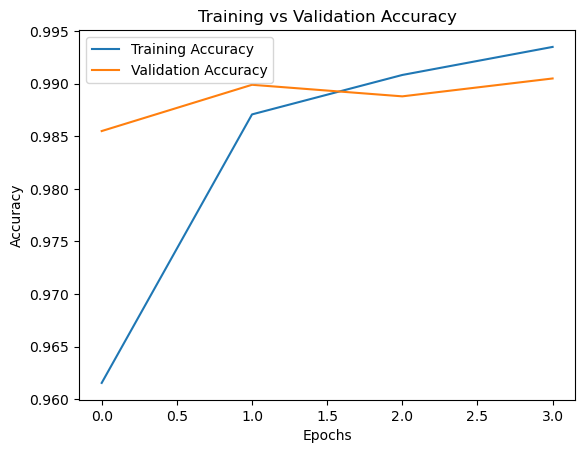

In [68]:
# Plotting accuracy and loss
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.show()

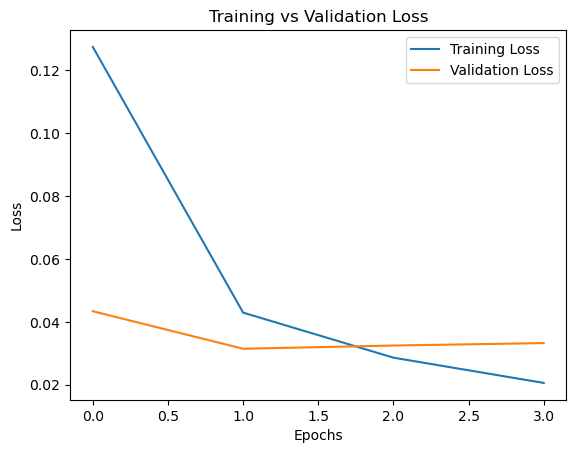

In [69]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.show()

# Evaluting the model

In [70]:
test_loss,test_acc=model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9863 - loss: 0.0421


# Visualize Perfomance

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


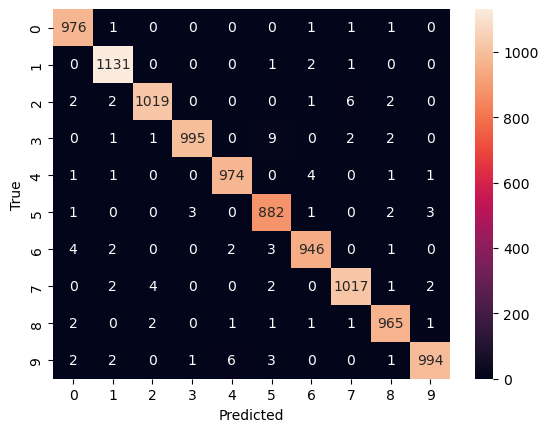

'              precision    recall  f1-score   support\n\n           0       0.99      1.00      0.99       980\n           1       0.99      1.00      0.99      1135\n           2       0.99      0.99      0.99      1032\n           3       1.00      0.99      0.99      1010\n           4       0.99      0.99      0.99       982\n           5       0.98      0.99      0.98       892\n           6       0.99      0.99      0.99       958\n           7       0.99      0.99      0.99      1028\n           8       0.99      0.99      0.99       974\n           9       0.99      0.99      0.99      1009\n\n    accuracy                           0.99     10000\n   macro avg       0.99      0.99      0.99     10000\nweighted avg       0.99      0.99      0.99     10000\n'

In [71]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
y_pred=model.predict(X_test)
y_pred_classes=np.argmax(y_pred,axis=1)

y_pred_classes

#confusion matrix
cm=confusion_matrix(y_test,y_pred_classes)
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

classification_report(y_test,y_pred_classes)

# Save the model

In [72]:
model.save("mnist_cnn_model.keras")  # native Keras format


#  MlFlow logging

In [73]:
import mlflow
import mlflow.tensorflow

In [74]:
with mlflow.start_run():
    mlflow.tensorflow.autolog()
    #autologs model,parms,metrics,loss curves
    model.fit(X_train,y_train,epochs=5,validation_split=0.1,batch_size=128)
    test_loss,test_acc=model.evaluate(X_test,y_test)
    mlflow.log_metric("test_loss",test_loss)
    mlflow.log_metric("test_accuracy",test_acc)
    #mlflow.keras.log_model(model, "mnist_cnn_model")


2025/05/01 16:11:50 WARNING mlflow.utils.autologging_utils: MLflow tensorflow autologging is known to be compatible with 2.7.4 <= tensorflow <= 2.18.0, but the installed version is 2.19.0. If you encounter errors during autologging, try upgrading / downgrading tensorflow to a compatible version, or try upgrading MLflow.


2025/05/01 16:11:50 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: When an mlflow-artifacts URI was supplied, the tracking URI must be a valid http or https URI, but it was currently set to file:///Users/anil/mlruns. Perhaps you forgot to set the tracking URI to the running MLflow server. To set the tracking URI, use either of the following methods:
1. Set the MLFLOW_TRACKING_URI environment variable to the desired tracking URI. `export MLFLOW_TRACKING_URI=http://localhost:5000`
2. Set the tracking URI programmatically by calling `mlflow.set_tracking_uri`. `mlflow.set_tracking_uri('http://localhost:5000')`


Epoch 1/5
418/422 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9942 - loss: 0.0210

2025/05/01 16:11:55 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: When an mlflow-artifacts URI was supplied, the tracking URI must be a valid http or https URI, but it was currently set to file:///Users/anil/mlruns. Perhaps you forgot to set the tracking URI to the running MLflow server. To set the tracking URI, use either of the following methods:
1. Set the MLFLOW_TRACKING_URI environment variable to the desired tracking URI. `export MLFLOW_TRACKING_URI=http://localhost:5000`
2. Set the tracking URI programmatically by calling `mlflow.set_tracking_uri`. `mlflow.set_tracking_uri('http://localhost:5000')`


422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9942 - loss: 0.0210 - val_accuracy: 0.9947 - val_loss: 0.0183
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9964 - loss: 0.0125 - val_accuracy: 0.9953 - val_loss: 0.0191
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9967 - loss: 0.0102 - val_accuracy: 0.9938 - val_loss: 0.0221
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9975 - loss: 0.0079 - val_accuracy: 0.9940 - val_loss: 0.0220
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9983 - loss: 0.0056 - val_accuracy: 0.9947 - val_loss: 0.0217
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


2025/05/01 16:12:20 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during tensorflow autologging: When an mlflow-artifacts URI was supplied, the tracking URI must be a valid http or https URI, but it was currently set to file:///Users/anil/mlruns. Perhaps you forgot to set the tracking URI to the running MLflow server. To set the tracking URI, use either of the following methods:
1. Set the MLFLOW_TRACKING_URI environment variable to the desired tracking URI. `export MLFLOW_TRACKING_URI=http://localhost:5000`
2. Set the tracking URI programmatically by calling `mlflow.set_tracking_uri`. `mlflow.set_tracking_uri('http://localhost:5000')`


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9890 - loss: 0.0348


In [75]:
import os
os.getcwd()

'/Users/anil'